In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df_sber = pd.read_csv("..\\data\\order_books\\SBER_02.csv", header=0)
df_sber['SBER'] = df_sber['MidPriceClose'].pct_change()
#df_sber['log_rtn'] = np.log(df_sber['MidPriceClose']/df_sber['MidPriceClose'].shift(1))
df_sber.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df_srh6 = pd.read_csv("..\\data\\order_books\\SRH6_02.csv", header=0)
df_srh6['SBRF-3.26'] = df_srh6['MidPriceClose'].pct_change()
df_srh6.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df_srm6 = pd.read_csv("..\\data\\order_books\\SRM6_02.csv", header=0)
df_srm6['SBRF-6.26'] = df_srm6['MidPriceClose'].pct_change()
df_srm6.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df_sru6 = pd.read_csv("..\\data\\order_books\\SRU6_02.csv", header=0)
df_sru6['SBRF-9.26'] = df_sru6['MidPriceClose'].pct_change()
df_sru6.drop(columns=['MidPriceClose', 'MidPriceAvg', 'MidPriceStdDev', 'SpreadAvg', 'Count'], inplace=True)

df1 = pd.merge(df_sber, df_srh6, on='TimeUtc')
df2 = pd.merge(df1, df_srm6, on='TimeUtc')
df = pd.merge(df2, df_sru6, on='TimeUtc')


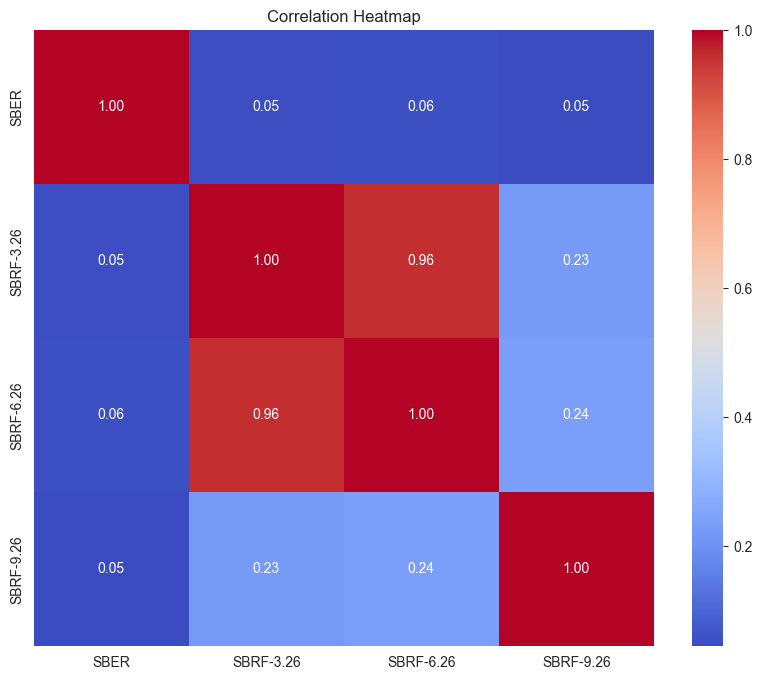

In [66]:
df['SBER']= df['SBER'].shift(1)
#df['SBRF-3.26']= df['SBRF-3.26'].shift(1)

df.dropna(inplace=True)

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()
